# Break Through Tech AI: Nestlé 1A Group
## Stage 2: Baseline Models

We have merged the User Reviews file and Item Metadata file into a Pandas dataframe, to be preprocessed for usage in two baseline models: Logistic Regression and Naive Bayes.

### Step 1. Loading DataFrame and EDA

#### Update, Install, and Import Python Libraries

In [1]:
# %pip install --upgrade pip
# %pip install contractions
# %pip install -q datasets huggingface_hub pyarrow pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install scikit-learn
# %pip install seaborn

In [2]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from tqdm import tqdm
import gc
import glob
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import sklearn
import re

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### Import DataFrame

In [4]:
file_pattern = 'top_data/**/*.parquet' 
parquet_files = glob.glob(file_pattern, recursive=True)
 
# Reads each parquet file and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(fp) for fp in parquet_files], ignore_index=True)

In [5]:
df.shape

(1061601, 18)

In [6]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_meta,main_category,average_rating,rating_number,price,details,year_quarter,Flavor
0,2.0,The coconut overpowers the coffee. Not a favo...,No coffee taste,[],B003G52BN0,B007OYG9AA,AEL5UWA7CAG45FN7GZEG7SE4XHUA,2018-07-21 16:57:57.788,0,True,Green Mountain Coffee Roasters French Vanilla ...,Grocery,4.7,26679,NaN,"{'Age Range (Description)': None, 'Age Range D...",2018Q3,French Vanilla
1,5.0,Yum,Big box of Twix. Yum. Perfect for my child who...,[],B0029JE7RC,B071KL86P1,AG6G5IZRETKHWANDEC3N43ANN3YQ,2023-01-17 00:26:20.400,0,True,Twix TWIX Singles Size White Chocolate Caramel...,Grocery,4.4,1042,NaN,"{'Age Range (Description)': None, 'Age Range D...",2023Q1,Chocolate
2,1.0,Repeatedly sent the wrong number of cookies,Love these cookies. Don’t love the seller.<br ...,[],B0964H46TF,B09JGWP155,AEN6FHORVITRRZTUE4IFFPUDQUNQ,2022-07-21 04:54:52.430,2,True,Quest Nutrition Chocolate Cake Frosted Cookies...,Health & Personal Care,4.6,3693,26.64,"{'Age Range (Description)': None, 'Age Range D...",2022Q3,Chocolate
3,5.0,Potent and flavorful!,My girlfriend's Christmas tradition is to make...,[],B00F3OAKJ4,B07MCCC7YM,AEJQJMK5GZK4NAQ3L3XV76CJEUHA,2018-01-23 02:16:19.563,11,True,"LorAnn Cinnamon Oil SS Flavor, 1 dram bottle (...",Amazon Home,4.7,964,3.45,"{'Age Range (Description)': None, 'Age Range D...",2018Q1,Cinnamon
4,5.0,Five Stars,Grandkids loved it.,[],B07658D4CK,B07658D4CK,AEXLWUJLIVNRLVF6HRMKQLJEUXEQ,2018-01-17 13:41:15.576,0,True,Halloween Skull White Bucket with Assorted Cho...,Grocery,4.1,27,NaN,"{'Age Range (Description)': None, 'Age Range D...",2018Q1,Dark Chocolate


#### Define an Initial Column for Sentiment

In [7]:
def get_sentiment(rating):
    if rating < 3:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

In [8]:
df['sentiment'] = df['rating'].apply(get_sentiment)

#### Visualize Class Imbalance

In [12]:
df['sentiment'].value_counts()

sentiment
positive    793335
negative    201600
neutral      66666
Name: count, dtype: int64

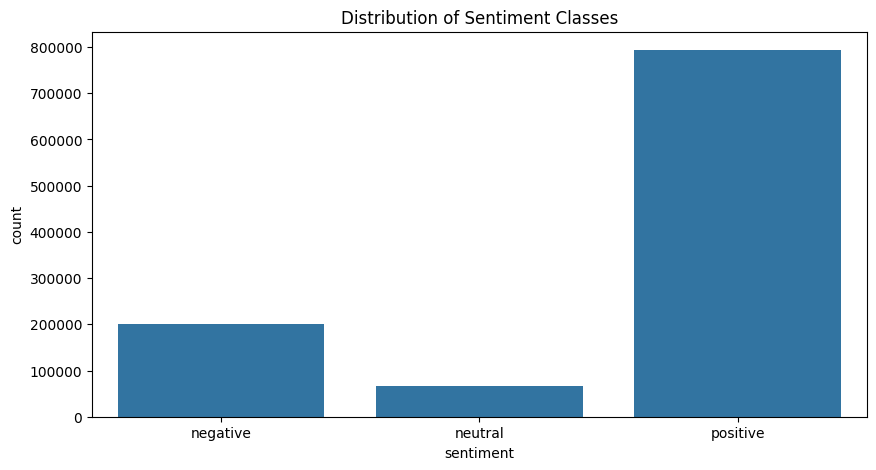

In [13]:
# Visualize the class distribution for ratings
plt.figure(figsize = (10, 5))
sns.countplot(data = df, x = 'sentiment', order = ['negative', 'neutral', 'positive'])
plt.title("Distribution of Sentiment Classes")
plt.show()

We must handle class imbalance in different ways for our two baseline models: Logistic Regression and Naive Bayes.

### Step 2. Data Preprocessing

##### Preprocessing Pipeline

In [26]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [27]:
df['text'] = df['text'].apply(clean_text)

### Step 3. Baseline Model Building \& Evaluation

##### Import Libraries for Model Building and Evaluation

In [28]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

##### Encode the Label: String to Numerical

In [29]:
# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the sentiment labels
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

# Display the mapping of labels to numbers
print("Label encoding mapping:")
for label, num in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label}: {num}")

Label encoding mapping:
negative: 0
neutral: 1
positive: 2


##### Split the data

In [30]:
X = df['text']    
y = df['sentiment_encoded']  

# 80% training, 20% testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

### Logistic Regression Model

In [35]:
tfidf_vectorizer = TfidfVectorizer(ngram_range = (1,2),      # Specifies the range of n-grams to be extracted.
                                   min_df = 50,              # A term must appear in at least 50 documents to be considered.
                                   max_df = 0.95)             # Remove overly common tokens 
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [36]:
lr_model = LogisticRegression(multi_class='multinomial',
                              class_weight='balanced', # handle class imbalance
                              solver='lbfgs', 
                              max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [37]:
# Use the predict() method to use the fitted model to predict the class labels for the test set.
y_pred_lr = lr_model.predict(X_test_tfidf)

In [38]:
# Use the predict_proba() method  to use the fitted model to predict class probabilities for the test set.
y_pred_proba_lr = lr_model.predict_proba(X_test_tfidf) # Shape: [n_samples, n_classes]

In [39]:
# Display LR Model Classification Report
print("Logistic Regression Classification Report:\n") 
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_report_df = pd.DataFrame(lr_report).transpose()
lr_report_df

Logistic Regression Classification Report:



,precision,recall,f1-score,support
0,0.812006,0.771713,0.791347,40506.000000
1,0.276382,0.616169,0.381598,13334.000000
2,0.979202,0.890334,0.932656,158481.000000
accuracy,0.850486,0.850486,0.850486,0.850486
macro avg,0.689197,0.759405,0.701867,212321.000000
weighted avg,0.903167,0.850486,0.871090,212321.000000


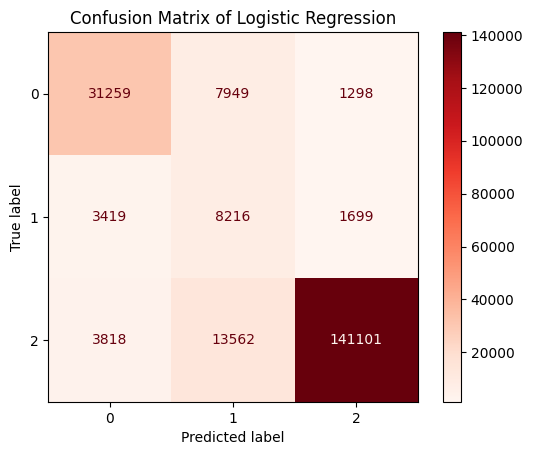

In [40]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
    
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title(f"Confusion Matrix of Logistic Regression")
plt.show()

### Naive Bayes Model

In [42]:
count_vectorizer = CountVectorizer(ngram_range = (1,2),     # Specifies the range of n-grams to be extracted.
                                   strip_accents='unicode', # Removes accents from characters by converting them to their closest ASCII representation.
                                   min_df = 50,              # A term must appear in at least 50 documents to be considered.
                                   max_df = 0.95,            # remove overly common tokens
                                   binary=False)

# Fit and transform on training data that creates a numerical matrix based on the learned vocabulary.
X_train_count = count_vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_count = count_vectorizer.transform(X_test)

In [43]:
print(f"Number of features: {len(count_vectorizer.get_feature_names_out())}") 
print(f"Show some feature names: {count_vectorizer.get_feature_names_out()[::1000]}")

Number of features: 49421
Show some feature names: ['00' 'again on' 'an ok' 'and too' 'as just' 'be all' 'bit bitter'
 'breaking bad' 'came out' 'chock' 'complained' 'cut open' 'different in'
 'earned' 'expected not' 'fish and' 'for yourself' 'given up' 'gross'
 'he could' 'imagine the' 'is false' 'it weren' 'larger quantity'
 'little stronger' 'marshall' 'months expired' 'named' 'not until'
 'oil to' 'or two' 'pancakes' 'pouch and' 'quality this' 'replacement the'
 'score' 'sites' 'something they' 'strength of' 'taste tested' 'that says'
 'the opposite' 'these coconut' 'this with' 'to suck' 'unpleasant'
 'want coffee' 'weird but' 'will re' 'yes please']


In [44]:
# Train Naive Bayes
nb_model = MultinomialNB(class_prior=[1/3, 1/3, 1/3]) # equal class prior probabilities
nb_model.fit(X_train_count, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,"[0.3333333333333333, 0.3333333333333333, ...]"


In [45]:
# Use the predict() method to use the fitted model to predict the class labels for the test set.
y_pred_nb = nb_model.predict(X_test_count)

In [46]:
# Use the predict_proba() method  to use the fitted model to predict class probabilities for the test set.
y_pred_proba_nb = nb_model.predict_proba(X_test_count)

In [47]:
# Display NB Model Classification Report
print("Naive Bayes Classification Report:\n") 
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
nb_report_df = pd.DataFrame(nb_report).transpose()
nb_report_df

Naive Bayes Classification Report:



,precision,recall,f1-score,support
0,0.763198,0.749840,0.756460,40506.00000
1,0.242658,0.626444,0.349813,13334.00000
2,0.977017,0.851377,0.909880,158481.00000
accuracy,0.817880,0.817880,0.817880,0.81788
macro avg,0.660958,0.742553,0.672051,212321.00000
weighted avg,0.890107,0.817880,0.845438,212321.00000


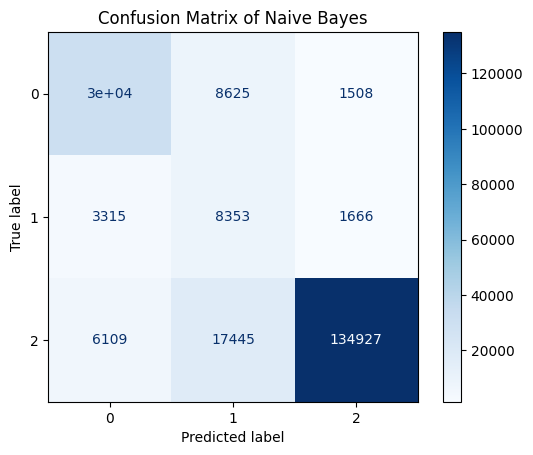

In [48]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)
    
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)  # Uses blue shades
plt.title(f"Confusion Matrix of Naive Bayes")
plt.show()